# German Traffic Sign Recognition (GTSRB) - Exploratory Data Analysis

This notebook explores the GTSRB dataset structure, class distribution, image properties, and provides visual samples of all 43 traffic sign classes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import random

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
random.seed(42)

# Base data directory (relative path)
DATA_DIR = '../data'

## 1. Load and Inspect the Dataset

We load `Train.csv` and `Test.csv` which contain metadata about each image including its path, dimensions, ROI coordinates, and class label.

In [2]:
train_df = pd.read_csv(os.path.join(DATA_DIR, 'Train.csv'))
test_df = pd.read_csv(os.path.join(DATA_DIR, 'Test.csv'))

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape:  {test_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\n--- Train.csv (first 5 rows) ---")
train_df.head()

Train set shape: (39209, 8)
Test set shape:  (12630, 8)

Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']

--- Train.csv (first 5 rows) ---


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


In [3]:
print(f"--- Test.csv (first 5 rows) ---")
test_df.head()

--- Test.csv (first 5 rows) ---


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


## 2. Class Distribution

Let's examine how images are distributed across the 43 classes. An imbalanced dataset can bias the model toward majority classes.

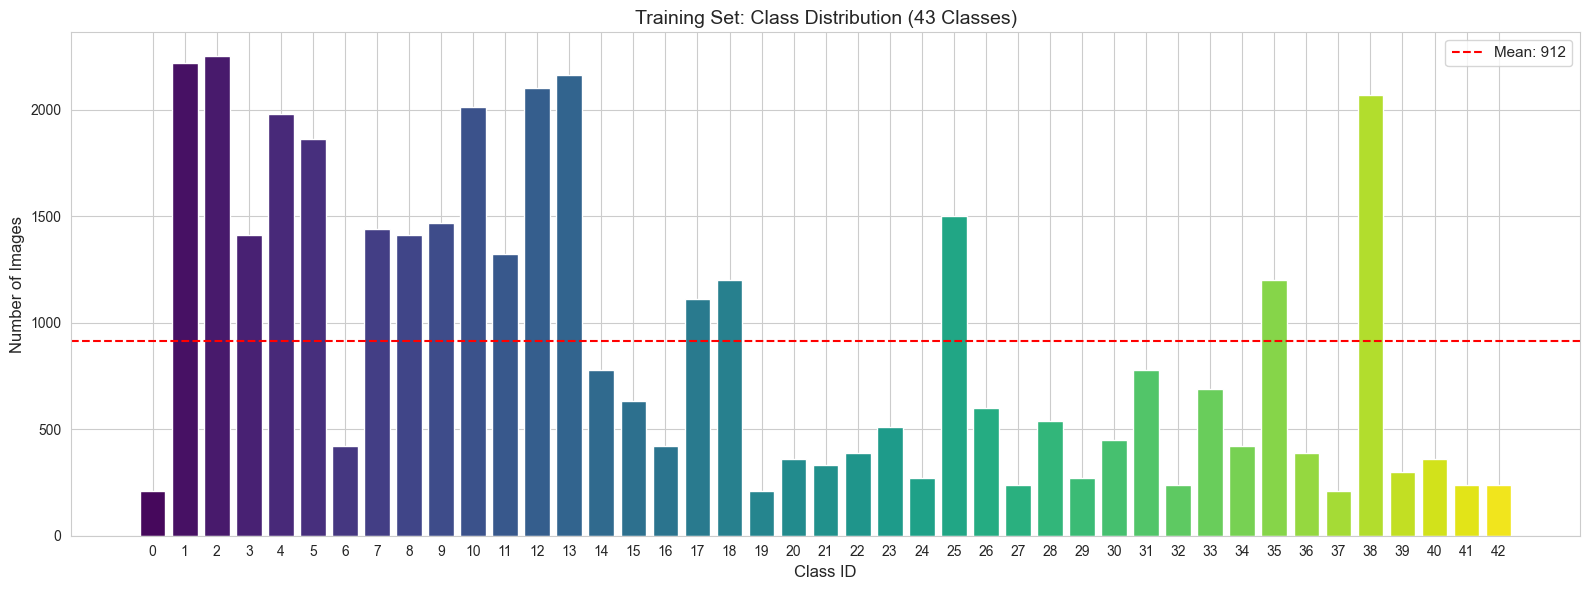


Imbalance ratio (max/min): 10.7x
Most samples:  Class 2 with 2250 images
Fewest samples: Class 0 with 210 images


In [4]:
class_counts = train_df['ClassId'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(16, 6))
bars = ax.bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', n_colors=43))
ax.set_xlabel('Class ID', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Training Set: Class Distribution (43 Classes)', fontsize=14)
ax.set_xticks(range(43))
ax.axhline(y=class_counts.mean(), color='red', linestyle='--', label=f'Mean: {class_counts.mean():.0f}')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")
print(f"Most samples:  Class {class_counts.idxmax()} with {class_counts.max()} images")
print(f"Fewest samples: Class {class_counts.idxmin()} with {class_counts.min()} images")

**Observation:** The dataset is significantly imbalanced. Some classes have over 10x more samples than others. This suggests we may need data augmentation or class weighting during training.

## 3. Sample Images from Random Classes

Let's visualize 3 sample images from 10 randomly selected classes to get a feel for the data quality and variety.

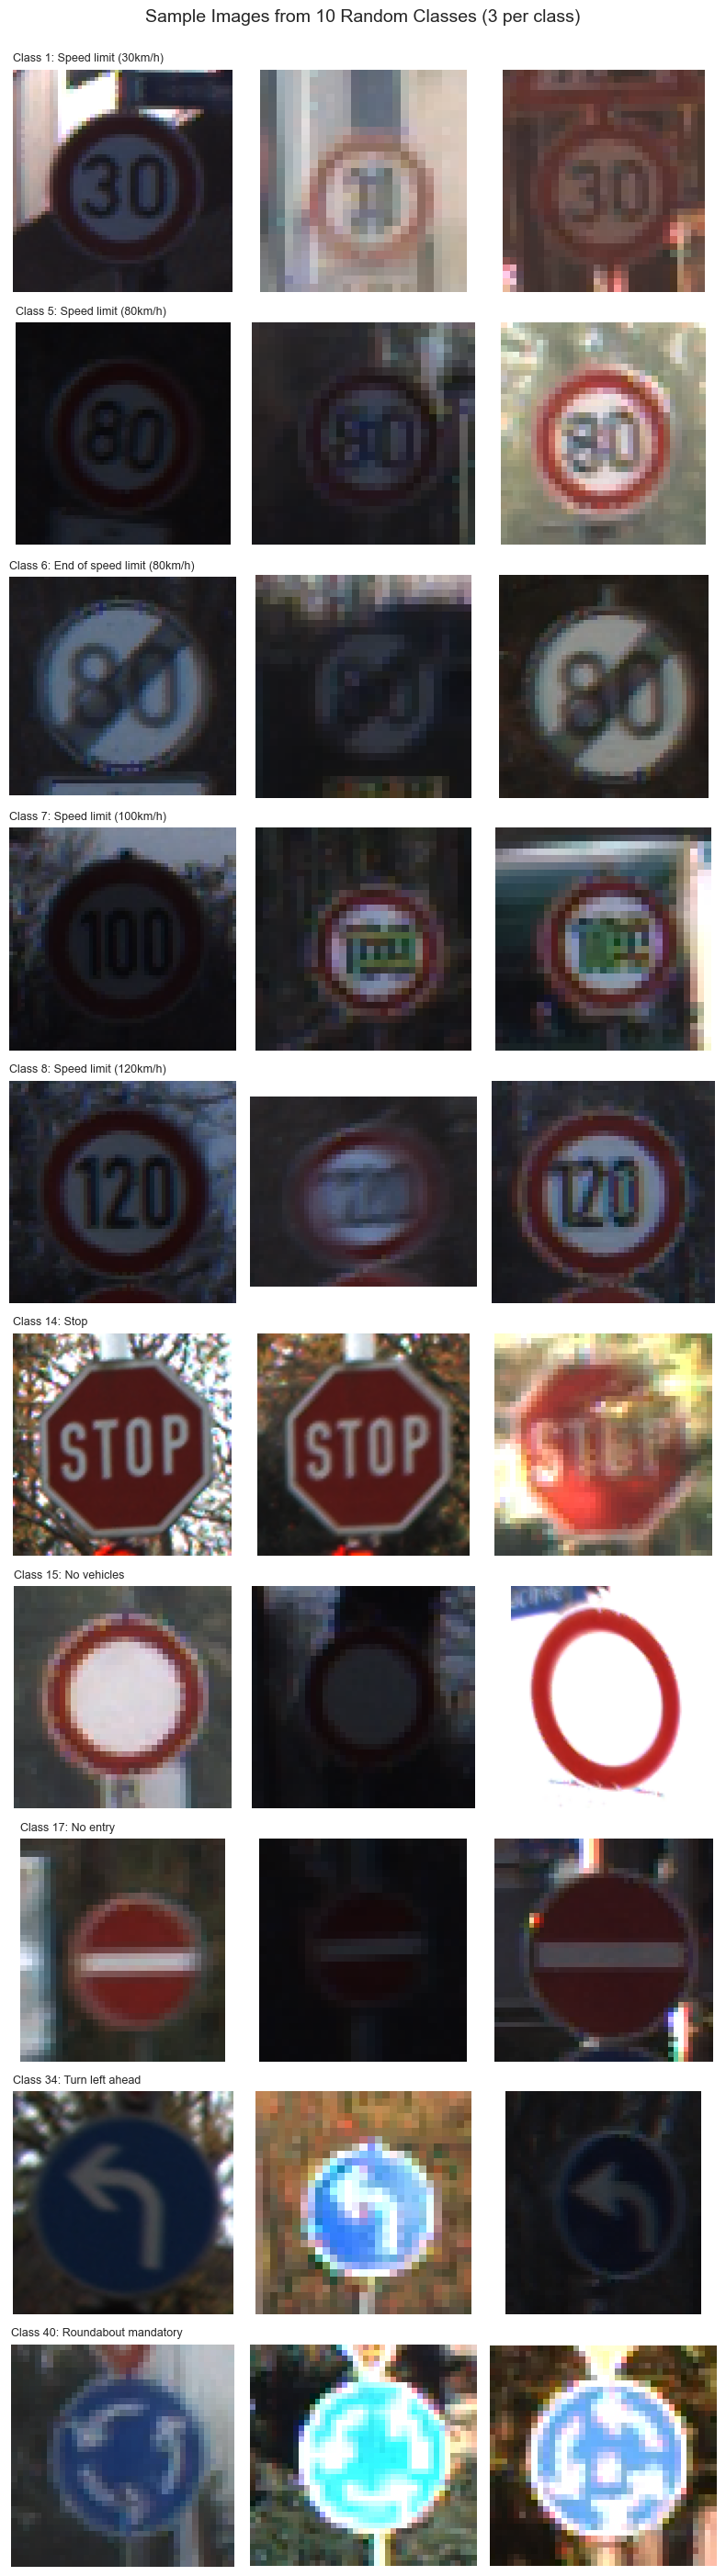

In [5]:
# GTSRB class names (standard mapping)
CLASS_NAMES = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing for vehicles over 3.5t',
    11: 'Right-of-way at next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Vehicles over 3.5t prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End of all speed and passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End of no passing by vehicles over 3.5t'
}

# Select 10 random classes
sample_classes = sorted(random.sample(range(43), 10))

fig, axes = plt.subplots(10, 3, figsize=(8, 28))
fig.suptitle('Sample Images from 10 Random Classes (3 per class)', fontsize=14, y=1.0)

for row, class_id in enumerate(sample_classes):
    class_images = train_df[train_df['ClassId'] == class_id].sample(3, random_state=42)
    for col, (_, img_row) in enumerate(class_images.iterrows()):
        img_path = os.path.join(DATA_DIR, img_row['Path'])
        img = Image.open(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f"Class {class_id}: {CLASS_NAMES[class_id]}", fontsize=9, loc='left')

plt.tight_layout()
plt.show()

**Observation:** Images vary significantly in brightness, contrast, and resolution. Some are quite small and blurry, which makes classification challenging. Data augmentation and normalization will be important preprocessing steps.

## 4. Image Size Distribution

Understanding the distribution of image dimensions helps us choose an appropriate input size for the model.

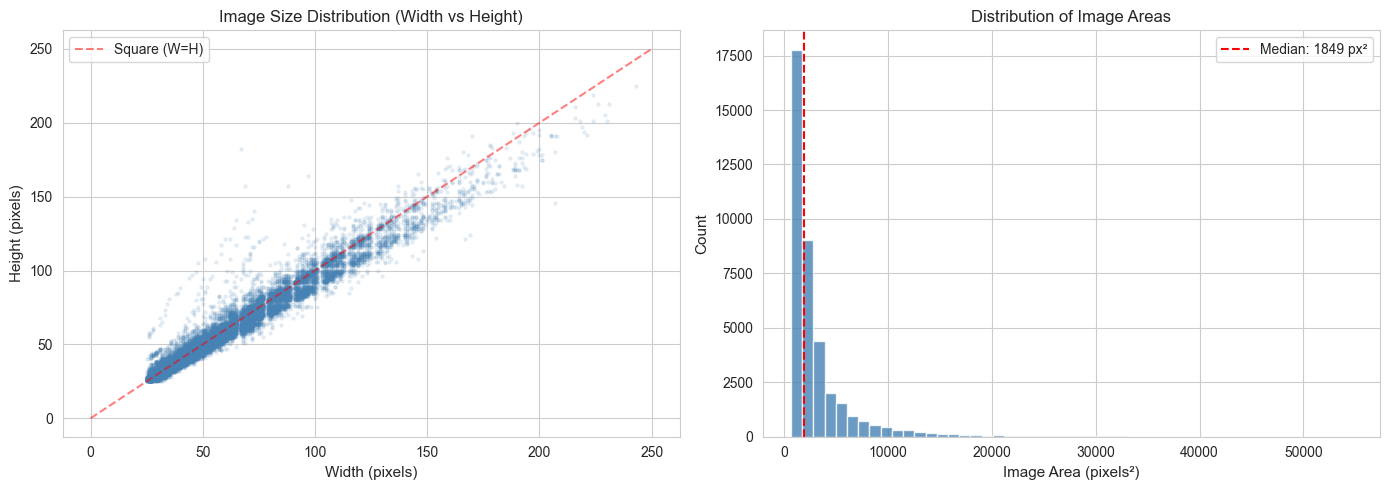

Width  - Min: 25, Max: 243, Mean: 50.8
Height - Min: 25, Max: 225, Mean: 50.3


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Width vs Height
axes[0].scatter(train_df['Width'], train_df['Height'], alpha=0.1, s=5, c='steelblue')
axes[0].set_xlabel('Width (pixels)', fontsize=11)
axes[0].set_ylabel('Height (pixels)', fontsize=11)
axes[0].set_title('Image Size Distribution (Width vs Height)', fontsize=12)
axes[0].plot([0, 250], [0, 250], 'r--', alpha=0.5, label='Square (W=H)')
axes[0].legend()

# Histogram of image areas
areas = train_df['Width'] * train_df['Height']
axes[1].hist(areas, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Image Area (pixels²)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Distribution of Image Areas', fontsize=12)
axes[1].axvline(areas.median(), color='red', linestyle='--', label=f'Median: {areas.median():.0f} px²')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Width  - Min: {train_df['Width'].min()}, Max: {train_df['Width'].max()}, Mean: {train_df['Width'].mean():.1f}")
print(f"Height - Min: {train_df['Height'].min()}, Max: {train_df['Height'].max()}, Mean: {train_df['Height'].mean():.1f}")

**Observation:** Images are mostly near-square but vary widely in size (from ~20px to ~200px+). Most images are relatively small. We'll need to resize all images to a consistent size (e.g., 32x32 or 48x48) for the model.

## 5. Class Names from Meta.csv

Let's load the metadata and map class IDs to their human-readable names.

In [7]:
meta_df = pd.read_csv(os.path.join(DATA_DIR, 'Meta.csv'))
print(f"Meta.csv shape: {meta_df.shape}")
print(f"Columns: {list(meta_df.columns)}\n")
meta_df.head(10)

Meta.csv shape: (43, 5)
Columns: ['Path', 'ClassId', 'ShapeId', 'ColorId', 'SignId']



,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22
5,Meta/12.png,12,2,2,2.3
6,Meta/13.png,13,4,0,2.1
7,Meta/14.png,14,3,0,2.2
8,Meta/15.png,15,1,0,3.1
9,Meta/16.png,16,1,0,3.3


In [8]:
# Display full class name mapping
print("Complete GTSRB Class Mapping:")
print("=" * 55)
for class_id in sorted(CLASS_NAMES.keys()):
    count = class_counts.get(class_id, 0)
    print(f"  Class {class_id:2d}: {CLASS_NAMES[class_id]:<45s} ({count} images)")

Complete GTSRB Class Mapping:
  Class  0: Speed limit (20km/h)                          (210 images)
  Class  1: Speed limit (30km/h)                          (2220 images)
  Class  2: Speed limit (50km/h)                          (2250 images)
  Class  3: Speed limit (60km/h)                          (1410 images)
  Class  4: Speed limit (70km/h)                          (1980 images)
  Class  5: Speed limit (80km/h)                          (1860 images)
  Class  6: End of speed limit (80km/h)                   (420 images)
  Class  7: Speed limit (100km/h)                         (1440 images)
  Class  8: Speed limit (120km/h)                         (1410 images)
  Class  9: No passing                                    (1470 images)
  Class 10: No passing for vehicles over 3.5t             (2010 images)
  Class 11: Right-of-way at next intersection             (1320 images)
  Class 12: Priority road                                 (2100 images)
  Class 13: Yield                   

## 6. Dataset Statistics

Summary statistics about the dataset size and per-class distribution.

In [9]:
print("=" * 50)
print("         GTSRB DATASET STATISTICS")
print("=" * 50)
print(f"  Total training images:   {len(train_df):,}")
print(f"  Total test images:       {len(test_df):,}")
print(f"  Total images:            {len(train_df) + len(test_df):,}")
print(f"  Number of classes:       {train_df['ClassId'].nunique()}")
print(f"")
print(f"  Images per class (train):")
print(f"    Min:   {class_counts.min():,} (Class {class_counts.idxmin()}: {CLASS_NAMES[class_counts.idxmin()]})")
print(f"    Max:   {class_counts.max():,} (Class {class_counts.idxmax()}: {CLASS_NAMES[class_counts.idxmax()]})")
print(f"    Mean:  {class_counts.mean():,.1f}")
print(f"    Std:   {class_counts.std():,.1f}")
print(f"    Median: {class_counts.median():,.0f}")
print("=" * 50)

         GTSRB DATASET STATISTICS
  Total training images:   39,209
  Total test images:       12,630
  Total images:            51,839
  Number of classes:       43

  Images per class (train):
    Min:   210 (Class 0: Speed limit (20km/h))
    Max:   2,250 (Class 2: Speed limit (50km/h))
    Mean:  911.8
    Std:   695.9
    Median: 600


## 7. All 43 Traffic Sign Classes

A visual overview of all classes using the reference images from the `Meta/` folder.

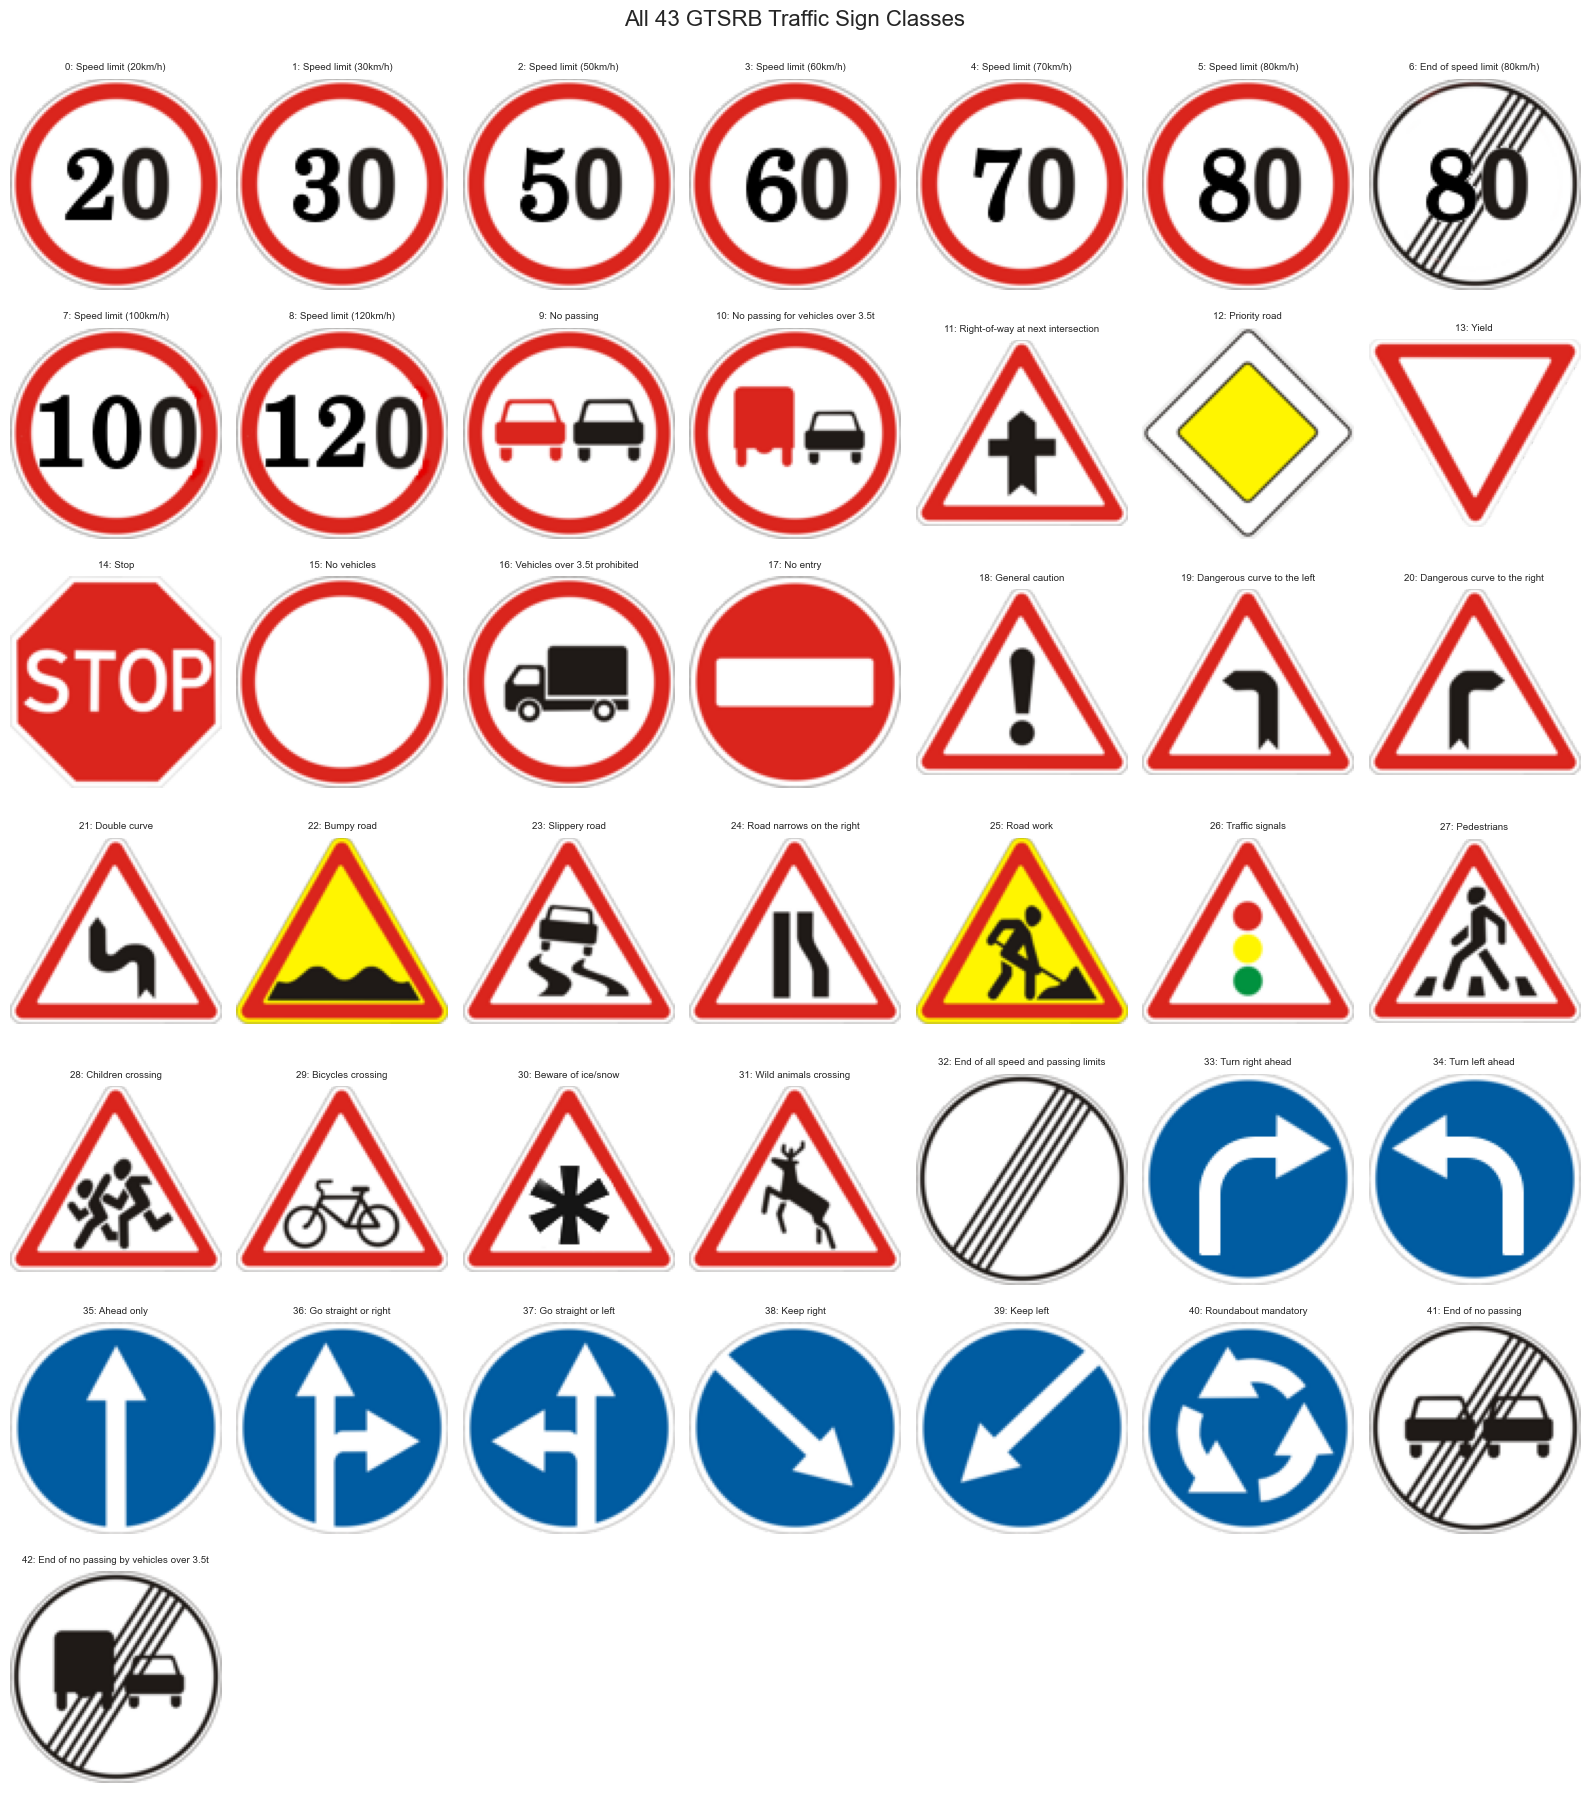

In [10]:
# Display all 43 classes in a grid using Meta images
n_cols = 7
n_rows = 7  # 7x7 = 49 cells, enough for 43 classes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 18))
fig.suptitle('All 43 GTSRB Traffic Sign Classes', fontsize=16, y=1.0)

for idx in range(n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    ax = axes[row, col]
    
    if idx < 43:
        img_path = os.path.join(DATA_DIR, 'Meta', f'{idx}.png')
        if os.path.exists(img_path):
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"{idx}: {CLASS_NAMES[idx]}", fontsize=7, wrap=True)
        else:
            ax.text(0.5, 0.5, f'Class {idx}\nNo image', ha='center', va='center', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

## Summary

Key findings from this EDA:

1. **Dataset size:** ~39,000 training images and ~12,600 test images across 43 classes
2. **Class imbalance:** Significant imbalance exists (up to ~10x ratio between largest and smallest classes). Consider oversampling, augmentation, or weighted loss.
3. **Image quality:** Images vary in size, lighting, and clarity. Many are small (~30x30 pixels).
4. **Preprocessing needs:** All images must be resized to a uniform dimension. Normalization and augmentation will improve robustness.
5. **Class variety:** The 43 classes cover speed limits, prohibitions, warnings, and mandatory signs with distinct visual patterns.